
# Data Visualization and Statistical Analysis Lab  
**Name:** Aryan Shrestha  
**Course:** MSCS 634 – Data Mining  
**Lab Title:** Data Visualization, Preprocessing, and Statistical Analysis

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

## Step 1: Data Collection

In [ ]:

# Load the specific Kaggle dataset:
# https://www.kaggle.com/datasets/konstantinognev/sample-superstorecsv
# Expected filename in /data: "SampleSuperstore.csv"
csv_path = "data/SampleSuperstore.csv"

df = pd.read_csv(csv_path, encoding="utf-8", low_memory=False)

# Normalize column names -> snake_case
def snake(s):
    return (
        s.strip()
        .replace("-", " ")
        .replace("/", " ")
        .replace("(", "")
        .replace(")", "")
        .lower()
        .replace(" ", "_")
    )

df.columns = [snake(c) for c in df.columns]

# Common columns present in this dataset
# Typical: 'order_date','ship_date','sales','quantity','discount','profit','region','category','sub_category'
# Parse order_date if present
if "order_date" in df.columns:
    df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

# Show first five rows (Screenshot Required)
display(df.head())
print("Columns:", df.columns.tolist())


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Columns: ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


## Step 2: Data Visualization

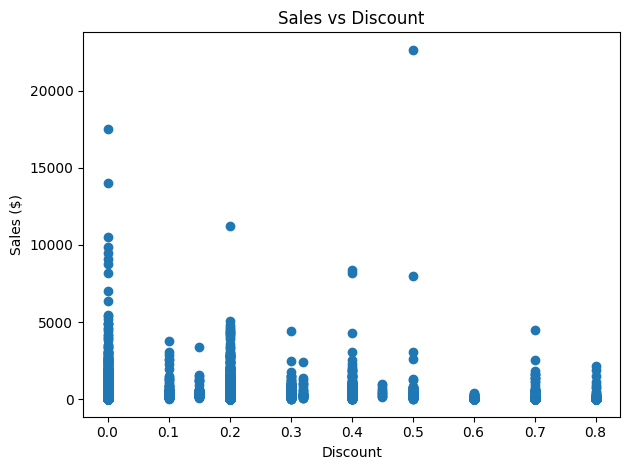

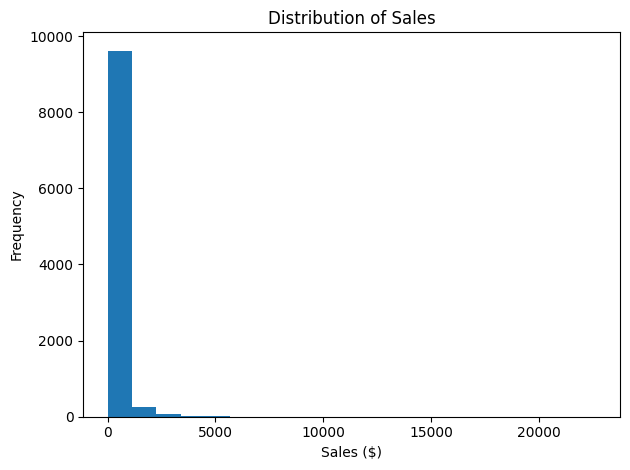

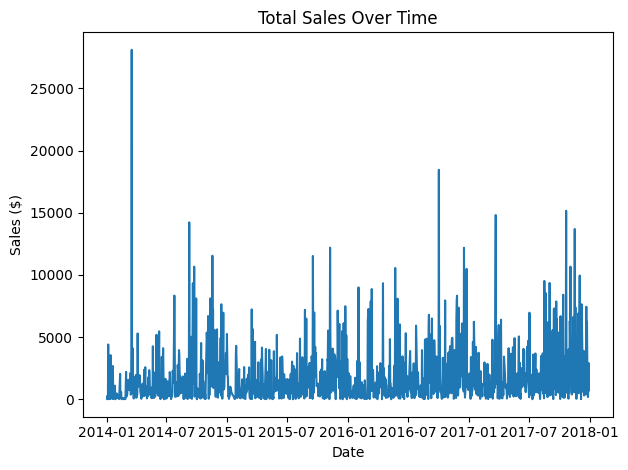

Insights:
- Scatter shows whether higher discounts correlate with changes in sales amount.
- Histogram indicates the right-skewed nature of sales and possible outliers.
- Line plot (if present) shows trend/seasonality across order dates.


In [ ]:

# Scatter: Discount vs Sales
plt.figure()
plt.scatter(df['discount'], df['sales'])
plt.title('Sales vs Discount')
plt.xlabel('Discount')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig("screenshots/step2_scatter_sales_vs_discount.png", dpi=150)
plt.show()

# Histogram: Sales distribution
plt.figure()
plt.hist(df['sales'].dropna(), bins=20)
plt.title('Distribution of Sales')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig("screenshots/step2_hist_sales.png", dpi=150)
plt.show()

# Line: Sales over time if order_date exists
if 'order_date' in df.columns:
    daily = df.dropna(subset=['order_date']).groupby('order_date', as_index=False)['sales'].sum()
    plt.figure()
    plt.plot(daily['order_date'], daily['sales'])
    plt.title('Total Sales Over Time')
    plt.xlabel('Date')
    plt.ylabel('Sales ($)')
    plt.tight_layout()
    plt.savefig("screenshots/step2_line_sales_over_time.png", dpi=150)
    plt.show()

print("Insights:")
print("- Scatter shows whether higher discounts correlate with changes in sales amount.")
print("- Histogram indicates the right-skewed nature of sales and possible outliers.")
print("- Line plot (if present) shows trend/seasonality across order dates.")


## Step 3: Data Preprocessing

### 3.1 Handling Missing Values

In [ ]:

# Screenshot BEFORE
print("Missing values BEFORE:")
missing_before = df.isnull().sum()
print(missing_before)

# Impute numerics with mean, categoricals with mode
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in numeric_cols]

# For numeric columns replace NaNs with the column mean.
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

# For non-numeric columns (categoricals / everything else) replace NaNs with the column mode (most frequent value).
for col in cat_cols:
    mode_val = df[col].mode(dropna=True)
    if len(mode_val) > 0:
        df[col] = df[col].fillna(mode_val.iloc[0])

print("\nMissing values AFTER:")
missing_after = df.isnull().sum()
print(missing_after)


Missing values BEFORE:
row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       1
category         0
sub_category     1
product_name     0
sales            0
quantity         0
discount         1
profit           1
dtype: int64

Missing values AFTER:
row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub_category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64


### 3.2 Outlier Detection and Removal (IQR on `sales`)

Q1=17.28, Q3=209.94, IQR=192.66, lower=-271.71, upper=498.93
Identified outliers: 1167


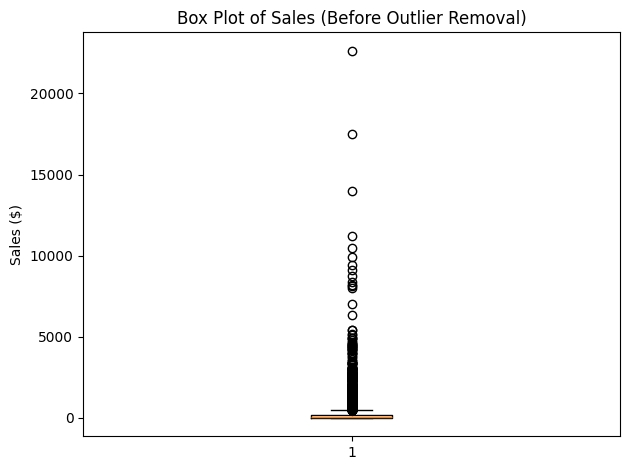

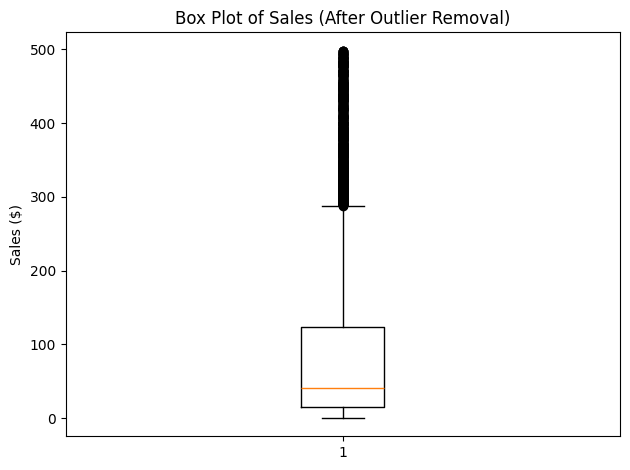

In [ ]:

Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, lower={lower:.2f}, upper={upper:.2f}")

outliers = df[(df['sales'] < lower) | (df['sales'] > upper)]
print("Identified outliers:", len(outliers))

# Box before
plt.figure()
plt.boxplot(df['sales'], vert=True)
plt.title('Box Plot of Sales (Before Outlier Removal)')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig("screenshots/step3_box_before.png", dpi=150)
plt.show()

df_clean = df[(df['sales'] >= lower) & (df['sales'] <= upper)].copy()

# Box after
plt.figure()
plt.boxplot(df_clean['sales'], vert=True)
plt.title('Box Plot of Sales (After Outlier Removal)')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig("screenshots/step3_box_after.png", dpi=150)
plt.show()


### 3.3 Data Reduction (Sampling & Dropping Columns)

Applied sampling by reducing the sample size by 50%.  
Dropped rell relevent column like the postal_code.

In [ ]:

# 50% sample for demonstration
df_sample = df_clean.sample(frac=0.5, random_state=42).copy()

# Drop a less relevant column (example: 'postal_code' if present)
before_cols = df_sample.columns.tolist()
drop_cols = [c for c in ['postal_code'] if c in df_sample.columns]
df_reduced = df_sample.drop(columns=drop_cols) if drop_cols else df_sample.copy()
after_cols = df_reduced.columns.tolist()

print("Columns before:", before_cols)
print("Columns after :", after_cols)


Columns before: ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']
Columns after : ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


### 3.4 Data Scaling and Discretization

,row_id,sales,quantity,discount,profit
1152,1153,3.640,2,0.0,1.6380
9016,9017,11.416,1,0.2,3.8529
6910,6911,115.960,2,0.0,25.5112
7043,7044,198.744,4,0.3,-14.1960
7512,7513,239.456,7,0.2,17.9592


,row_id,sales,quantity,discount,profit
1152,0.115292,0.006205,0.076923,0.000,0.778157
9016,0.902322,0.021849,0.000000,0.250,0.780402
6910,0.691553,0.232176,0.076923,0.000,0.802357
7043,0.704864,0.398725,0.230769,0.375,0.762106
7512,0.751801,0.480632,0.461538,0.250,0.794702


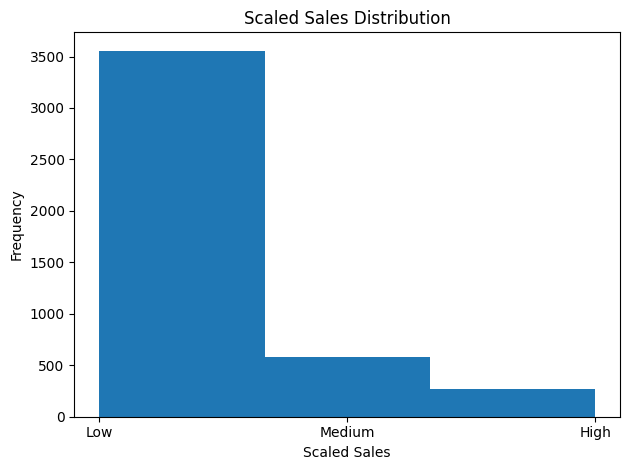

In [ ]:

# Select numeric columns for scaling
num_cols = df_reduced.select_dtypes(include=[np.number]).columns.tolist()

# Show before (head)
display(df_reduced[num_cols].head())

# Min-Max Scaling
mms = MinMaxScaler()
df_scaled = df_reduced.copy()
df_scaled[num_cols] = mms.fit_transform(df_scaled[num_cols])

# Show after (head)
display(df_scaled[num_cols].head())

# Discretize sales into 3 bins
df_scaled['sales_category'] = pd.cut(df_scaled['sales'], bins=3, labels=['Low', 'Medium', 'High'])

# Save histogram
plt.figure()
plt.hist(df_scaled['sales_category'].dropna(), bins=3)
plt.title('Scaled Sales Distribution')
plt.xlabel('Scaled Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig("screenshots/step3_scaled_sales_hist.png", dpi=150)
plt.show()


## Step 4: Statistical Analysis

### 4.1 General Overview (.info and .describe)

In [ ]:

df_scaled.info()
display(df_scaled.describe())


<class 'pandas.core.frame.DataFrame'>
Index: 4414 entries, 1152 to 7059
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   row_id          4414 non-null   float64       
 1   order_id        4414 non-null   object        
 2   order_date      4414 non-null   datetime64[ns]
 3   ship_date       4414 non-null   object        
 4   ship_mode       4414 non-null   object        
 5   customer_id     4414 non-null   object        
 6   customer_name   4414 non-null   object        
 7   segment         4414 non-null   object        
 8   country         4414 non-null   object        
 9   city            4414 non-null   object        
 10  state           4414 non-null   object        
 11  region          4414 non-null   object        
 12  product_id      4414 non-null   object        
 13  category        4414 non-null   object        
 14  sub_category    4414 non-null   object        
 15  produc

,row_id,order_date,sales,quantity,discount,profit
count,4414.000000,4414,4414.000000,4414.000000,4414.000000,4414.000000
mean,0.497604,2016-05-02 12:21:12.315360256,0.183274,0.201335,0.197657,0.787425
min,0.000000,2014-01-04 00:00:00,0.000000,0.000000,0.000000,0.000000
25%,0.245146,2015-06-04 00:00:00,0.029208,0.076923,0.000000,0.778190
50%,0.500450,2016-06-20 12:00:00,0.079327,0.153846,0.250000,0.783986
75%,0.746973,2017-05-06 00:00:00,0.244237,0.307692,0.250000,0.797757
max,1.000000,2017-12-30 00:00:00,1.000000,1.000000,1.000000,1.000000
std,0.290050,NaN,0.226958,0.162793,0.262201,0.046583


### 4.2 Central Tendency Measures

In [ ]:

min_val = df_scaled['sales'].min()
max_val = df_scaled['sales'].max()
mean_val = df_scaled['sales'].mean()
median_val = df_scaled['sales'].median()
mode_val = df_scaled['sales'].mode().iloc[0]

print("Min   :", min_val)
print("Max   :", max_val)
print("Mean  :", mean_val)
print("Median:", median_val)
print("Mode  :", mode_val)


Min   : 0.0
Max   : 0.9999999999999999
Mean  : 0.18327428944918445
Median: 0.07932739702326104
Mode  : 0.02495503506661248


### 4.3 Dispersion Measures

In [ ]:

range_val = max_val - min_val
Q1 = df_scaled['sales'].quantile(0.25)
Q3 = df_scaled['sales'].quantile(0.75)
iqr = Q3 - Q1
variance = df_scaled['sales'].var()
std_dev = df_scaled['sales'].std()

print("Range     :", range_val)
print("Q1, Q3    :", Q1, Q3)
print("IQR       :", iqr)
print("Variance  :", variance)
print("Std Dev   :", std_dev)


Range     : 0.9999999999999999
Q1, Q3    : 0.029208094090380516 0.244237044667179
IQR       : 0.21502895057679847
Variance  : 0.05150977635294266
Std Dev   : 0.22695765321518166


### 4.4 Correlation Analysis

,row_id,sales,quantity,discount,profit
row_id,1.000000,-0.000499,-0.015555,0.014018,-0.008662
sales,-0.000499,1.000000,0.141272,-0.067554,0.174191
quantity,-0.015555,0.141272,1.000000,0.016428,0.089722
discount,0.014018,-0.067554,0.016428,1.000000,-0.456213
profit,-0.008662,0.174191,0.089722,-0.456213,1.000000


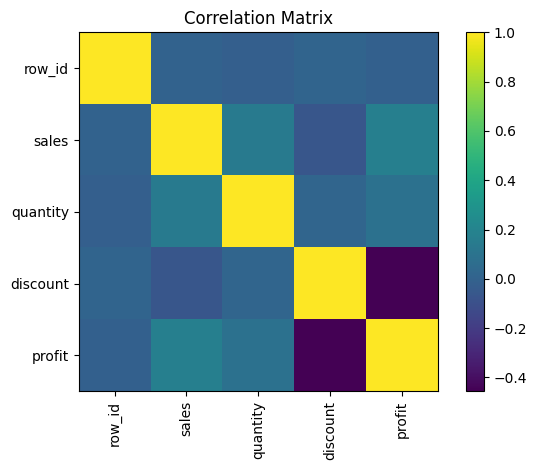

In [ ]:

corr = df_scaled.select_dtypes(include=[np.number]).corr()
display(corr)

plt.figure()
plt.imshow(corr, interpolation='nearest')
plt.title('Correlation Matrix')
plt.colorbar()
tick_marks = np.arange(len(corr.columns))
plt.xticks(tick_marks, corr.columns, rotation=90)
plt.yticks(tick_marks, corr.columns)
plt.tight_layout()
plt.savefig("screenshots/step4_corr_matrix.png", dpi=200, bbox_inches='tight')
plt.show()
